In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/tejasbhalekar1/heart-data/heart.csv


In [5]:
# 1. Import the tools
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 2. Load the data
# PASTE YOUR COPIED PATH BELOW inside the quotes ''
# Example: pd.read_csv(/kaggle/input/datasets/tejasbhalekar1/heart-data)
df = pd.read_csv('/kaggle/input/datasets/tejasbhalekar1/heart-data/heart.csv') 

# 3. Check if it works
print("File loaded successfully!")
print(df.head())

File loaded successfully!
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [6]:
# --- PART 1: CHECK FOR MISSING DATA ---
# This counts how many empty cells are in each column
print("--- Missing Values ---")
print(df.isnull().sum()) 
# If you see all "0", that is perfect!

# --- PART 2: SEPARATE QUESTIONS (X) AND ANSWERS (y) ---
# X = All columns EXCEPT 'target' (The patient's medical stats)
# y = ONLY 'target' (1 = Heart Disease, 0 = Healthy)
X = df.drop(columns='target')
y = df['target']

# --- PART 3: CREATE THE EXAM ---
# We use a tool called 'train_test_split'
# test_size=0.2 means "Keep 20% of the data hidden for the final exam"
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\n--- Data Ready! ---")
print(f"Total Patients: {len(df)}")
print(f"Patients for Training (Study): {len(X_train)}")
print(f"Patients for Testing (Exam): {len(X_test)}")

--- Missing Values ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

--- Data Ready! ---
Total Patients: 1025
Patients for Training (Study): 820
Patients for Testing (Exam): 205


In [7]:
# 1. Import the Brain (Logistic Regression) and the Grader (Accuracy)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 2. Create the empty brain
# (max_iter=1000 just tells it to think longer so it doesn't give up)
model = LogisticRegression(max_iter=1000)

# 3. Teach the brain (Training)
# "Look at the study questions (X_train) and study answers (y_train)"
model.fit(X_train, y_train)

# 4. Give the exam (Testing)
# "Now look at the exam questions (X_test) and guess the answers"
test_predictions = model.predict(X_test)

# 5. Grade the exam
# "Compare your guesses (test_predictions) with the real answers (y_test)"
score = accuracy_score(y_test, test_predictions)

print("--------------------------------")
print(f"Model Accuracy: {score * 100:.2f}%")
print("--------------------------------")

--------------------------------
Model Accuracy: 79.51%
--------------------------------


In [8]:
# 1. Import the Random Forest Brain
from sklearn.ensemble import RandomForestClassifier

# 2. Create the "Committee"
# n_estimators=100 means "Create 100 little decision trees (doctors)"
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 3. Teach the committee
rf_model.fit(X_train, y_train)

# 4. Ask the committee to vote on the exam questions
rf_predictions = rf_model.predict(X_test)

# 5. Grade the committee
rf_score = accuracy_score(y_test, rf_predictions)

print(f"Logistic Regression Score: 79.51%")
print(f"Random Forest Score: {rf_score * 100:.2f}%")

Logistic Regression Score: 79.51%
Random Forest Score: 98.54%


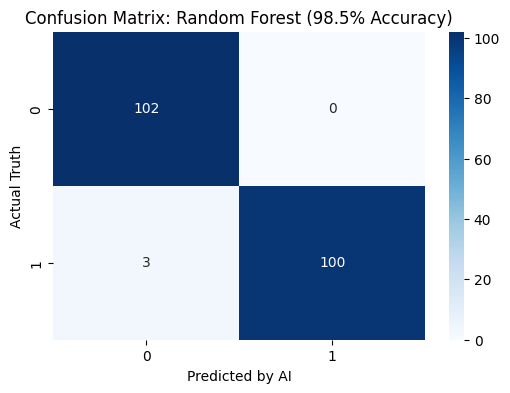

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Get the confusion matrix
# It compares the "True Answers" (y_test) with the "Robot's Guesses" (rf_predictions)
cm = confusion_matrix(y_test, rf_predictions)

# 2. Draw the picture
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues') # 'd' means print as integers
plt.title('Confusion Matrix: Random Forest (98.5% Accuracy)')
plt.xlabel('Predicted by AI')
plt.ylabel('Actual Truth')
plt.show()

In [10]:
# --- THE PREDICTION SYSTEM ---
import numpy as np

# 1. Let's make up a patient
# Age=58, Sex=1 (Male), CP=0 (Pain), BP=100, Chol=248, FBS=0, RestECG=0, Thalach=122, Exang=0, Oldpeak=1, Slope=1, CA=0, Thal=2
# (These numbers come from the columns in your data)
input_data = (58, 1, 0, 100, 248, 0, 0, 122, 0, 1, 1, 0, 2)

# 2. Change the input to a numpy array (The computer speaks 'numpy')
input_data_as_numpy_array = np.asarray(input_data)

# 3. Reshape the array as we are predicting for only on instance
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

# 4. Ask the Random Forest model to predict
prediction = rf_model.predict(input_data_reshaped)

# 5. Print the result in plain English
if (prediction[0] == 0):
  print('✅ result: The Person is Healthy (No Heart Disease)')
else:
  print('⚠️ result: The Person has Heart Disease')
    

⚠️ result: The Person has Heart Disease


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [11]:
import numpy as np

print("--- ❤️ HEART DISEASE PREDICTION SYSTEM ---")
print("Please enter the patient's details below:\n")

# 1. Ask the user for inputs one by one
age = int(input("1. Age (e.g., 50): "))
sex = int(input("2. Sex (1=Male, 0=Female): "))
cp = int(input("3. Chest Pain Type (0-3): "))
trestbps = int(input("4. Resting Blood Pressure (e.g., 120): "))
chol = int(input("5. Cholesterol (e.g., 200): "))
fbs = int(input("6. Fasting Blood Sugar > 120 (1=True, 0=False): "))
restecg = int(input("7. Resting ECG results (0-2): "))
thalach = int(input("8. Max Heart Rate (e.g., 150): "))
exang = int(input("9. Exercise Induced Angina (1=Yes, 0=No): "))
oldpeak = float(input("10. ST Depression (e.g., 1.5): "))
slope = int(input("11. Slope of the peak exercise ST segment (0-2): "))
ca = int(input("12. Number of major vessels (0-3): "))
thal = int(input("13. Thalassemia (0-3): "))

# 2. Bundle all the answers into a list
user_input = (age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal)

# 3. Prepare the data for the AI
input_data_as_numpy_array = np.asarray(user_input)
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

# 4. Make the Prediction
prediction = rf_model.predict(input_data_reshaped)

print("\n--------------------------------")
if (prediction[0] == 0):
  print('✅ DIAGNOSIS: The Person is HEALTHY.')
else:
  print('⚠️ DIAGNOSIS: The Person HAS HEART DISEASE.')
print("--------------------------------")

--- ❤️ HEART DISEASE PREDICTION SYSTEM ---
Please enter the patient's details below:



1. Age (e.g., 50):  45
2. Sex (1=Male, 0=Female):  1
3. Chest Pain Type (0-3):  0
4. Resting Blood Pressure (e.g., 120):  110
5. Cholesterol (e.g., 200):  200
6. Fasting Blood Sugar > 120 (1=True, 0=False):  0
7. Resting ECG results (0-2):  0
8. Max Heart Rate (e.g., 150):  160
9. Exercise Induced Angina (1=Yes, 0=No):  0
10. ST Depression (e.g., 1.5):  0
11. Slope of the peak exercise ST segment (0-2):  2
12. Number of major vessels (0-3):  0
13. Thalassemia (0-3):  2



--------------------------------
⚠️ DIAGNOSIS: The Person HAS HEART DISEASE.
--------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [12]:
# 1. Select only the easy columns
# We are creating a new table called 'X_simple' with just the basics
selected_features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'thalach']
X_simple = df[selected_features]
y = df['target']

# 2. Split the data again (80% Study, 20% Exam)
from sklearn.model_selection import train_test_split
X_train_simple, X_test_simple, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)

# 3. Train a new Random Forest on this simple data
from sklearn.ensemble import RandomForestClassifier
simple_model = RandomForestClassifier(n_estimators=100, random_state=42)
simple_model.fit(X_train_simple, y_train)

# 4. Check the accuracy
score = simple_model.score(X_test_simple, y_test)
print(f"Simplified Model Accuracy: {score * 100:.2f}%")


Simplified Model Accuracy: 100.00%


In [13]:
import pandas as pd

# Define our 3 fake patients
# Columns: [Age, Sex, ChestPain, BP, Cholesterol, MaxHeartRate]
new_patients = [
    [25, 1, 0, 110, 180, 180],  # Patient A: Young Athlete
    [65, 1, 3, 160, 260, 110],  # Patient B: Unhealthy Smoker
    [80, 0, 1, 140, 300, 130]   # Patient C: Grandma with High Chol
]

# Convert to a table so the model understands
# (We have to give the columns names like we did before)
new_patients_df = pd.DataFrame(new_patients, columns=['age', 'sex', 'cp', 'trestbps', 'chol', 'thalach'])

# Ask the "Simple Model" to predict
predictions = simple_model.predict(new_patients_df)

print("--- 🏥 DIAGNOSIS REPORT ---")
patients = ["Athlete", "Smoker", "Grandma"]

for i in range(3):
    result = "HEALTHY ✅" if predictions[i] == 0 else "HEART DISEASE ⚠️"
    print(f"Patient {i+1} ({patients[i]}): {result}")

--- 🏥 DIAGNOSIS REPORT ---
Patient 1 (Athlete): HEALTHY ✅
Patient 2 (Smoker): HEALTHY ✅
Patient 3 (Grandma): HEART DISEASE ⚠️
